# Preparando Imagens para treinamento

# Importando Bibliotecas

In [35]:
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
import cv2
import os
import matplotlib.pyplot as plt

# Lendo as Imagens

In [36]:
df_read = pd.read_json("datasets/dataset_pernambuco_25_turistas.json")

all_imgs = df_read["imagem"]
for i in range(len(all_imgs)):
    print(f"🎯 Encontradas {all_imgs[i]}")


🎯 Encontradas imagens/marco_zero_recife.jpg
🎯 Encontradas imagens/olinda.jpg
🎯 Encontradas imagens/porto_de_galinhas.jpg
🎯 Encontradas imagens/fernando_de_noronha.jpg
🎯 Encontradas imagens/caruaru.jpg
🎯 Encontradas imagens/museu_cais_do_sertao.jpg
🎯 Encontradas imagens/oficina_francisco_brennand.jpg
🎯 Encontradas imagens/teatro_santa_isabel.jpg
🎯 Encontradas imagens/garanhuns.jpg
🎯 Encontradas imagens/petrolina.jpg
🎯 Encontradas imagens/serra_talhada.jpg
🎯 Encontradas imagens/triunfo.jpg
🎯 Encontradas imagens/goiana.jpg
🎯 Encontradas imagens/arcoverde.jpg
🎯 Encontradas imagens/ilha_de_itamaraca.jpg
🎯 Encontradas imagens/engenho_massangana.jpg
🎯 Encontradas imagens/bonito.jpg
🎯 Encontradas imagens/bezerros.jpg
🎯 Encontradas imagens/instituto_ricardo_brennand.jpg
🎯 Encontradas imagens/praia_de_boa_viagem.jpg
🎯 Encontradas imagens/gravata.jpg
🎯 Encontradas imagens/vale_do_catimbau.jpg
🎯 Encontradas imagens/vitoria_de_santo_antao.jpg
🎯 Encontradas imagens/sertao_do_pajeu.jpg
🎯 Encontradas 

# Pré-Processamento de Imagens Usando Open-Cv2

In [37]:
def process_img(img_paths):
        transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        processed = []
        for path in img_paths:
              try:
                  img = Image.open(path).convert('RGB')
                  processed.append(transform(img))
              except Exception as e:
                print(f"❌ Erro em {path}: {e}")
    
        return torch.stack(processed) if processed else None

tensors = process_img(all_imgs[:10])

if tensors is not None: 
    print(f"✅ {len(tensors)} tensores prontos para ResNet-50")
    print(f"📐 Formato dos tensores: {tensors.shape}")
    print(f"🎯 Range dos valores: {tensors.min():.3f} a {tensors.max():.3f}")
else:
    print("❌ Nenhum tensor foi processado - verifique os caminhos das imagens")


✅ 10 tensores prontos para ResNet-50
📐 Formato dos tensores: torch.Size([10, 3, 224, 224])
🎯 Range dos valores: -2.118 a 2.640


🔄 Preview das imagens após pré-processamento ResNet-50:


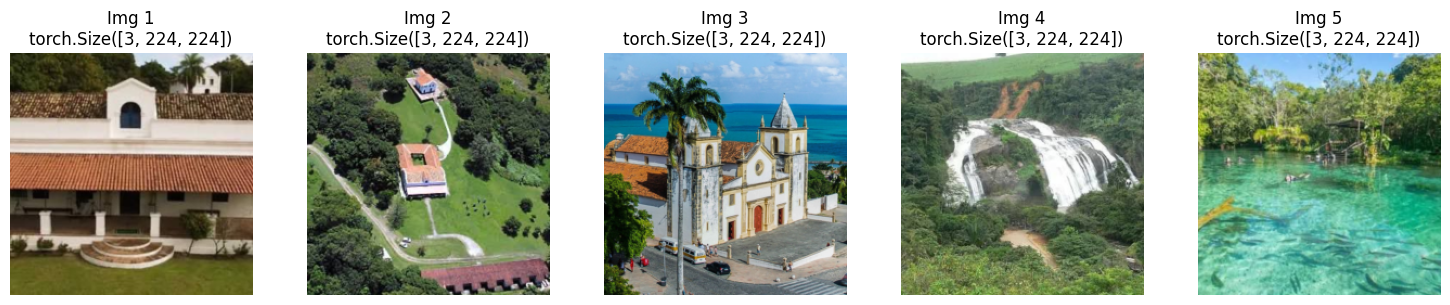

In [ ]:
def show_processed_preview(processed_tensors):
    num_images = len(processed_tensors)
    
    # Configurar o layout
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    
    # Se for apenas 1 imagem, converter para lista
    if num_images == 1:
        axes = [axes]
    
    for i in range(num_images):
        # Pegar tensor da imagem i
        tensor_img = processed_tensors[i]
        
        # Converter para numpy e ajustar dimensões (C, H, W) -> (H, W, C)
        img_np = tensor_img.numpy().transpose(1, 2, 0)
        
        # Desnormalizar para visualização
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)  # Limitar entre 0 e 1
        
        # Mostrar imagem
        axes[i].imshow(img_np)
        axes[i].set_title(f'Img {i+1}\n{tensor_img.shape}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Processar e mostrar as 5 primeiras
tensors = process_img(all_imgs[:5])

if tensors is not None:
    print("🔄 Preview das imagens após pré-processamento ResNet-50:")
    show_processed_preview(tensors)
else:
    print("❌ Não foi possível processar as imagens")